In [1]:
import numpy as np
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
# Define files and parameters

f_dir = 'results/model_distances/'
file_pairs = [
    ('learned_same', 'learned_opp'),
    ('sbert_same', 'sbert_opp')
]

param_dist = ['eu', 'cos']
param_emb = ['64']
param_margin = ['1']



In [3]:
import pandas as pd
from pathlib import Path
data = list()

input_file_pair = ('learned_same_cos_64_1.csv',
                   'learned_opp_cos_64_1.csv')

input_file_pair_sbert = ('sbert_same_cos_64_1.csv',
                         'sbert_opp_cos_64_1.csv')

data_learned = list()
for f in input_file_pair:
    file = Path(f_dir).joinpath(f)
    with open(file) as fin:
        values = np.array(list(map(lambda s: s.strip(), fin.readlines())), dtype=float)
    data_learned.extend([(f, v) for v in values])

data_sbert = list()
for f in input_file_pair_sbert:
    file = Path(f_dir).joinpath(f)
    with open(file) as fin:
        values = np.array(list(map(lambda s: s.strip(), fin.readlines())), dtype=float)
    data_sbert.extend([(f, v) for v in values])



df_learned = pd.DataFrame(data_learned, columns=['file', 'distance'])
df_sbert = pd.DataFrame(data_sbert, columns=['file', 'distance'])


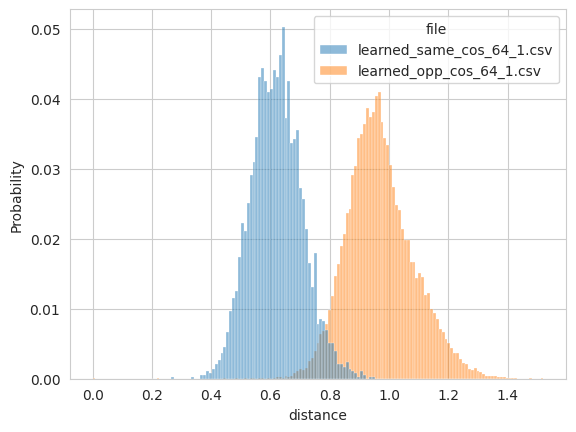

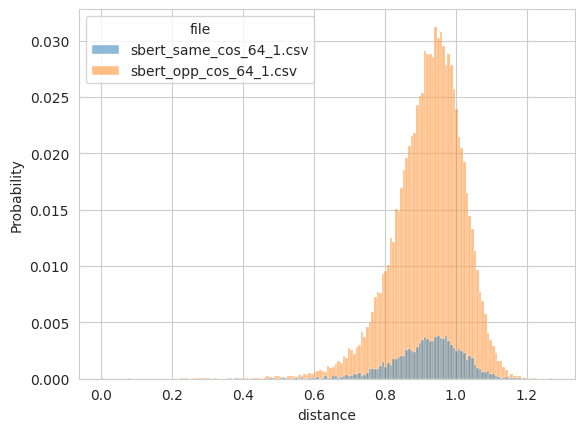

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df_learned, x='distance', 
             hue='file',
             stat='probability',
             common_norm=False)
plt.show();
plt.clf()

sns.histplot(data=df_sbert, x='distance', 
             hue='file',
             stat='probability',
             common_norm=False);


In [5]:
# Calculate distribution difference using Wasserstein Distance
# Also called Earth Mover's Distance
from scipy.stats import wasserstein_distance


# Get the distance values for each group
x_learned_same = df_learned[df_learned['file']==input_file_pair[0]]['distance']
x_learned_opp = df_learned[df_learned['file']==input_file_pair[1]]['distance']
x_sbert_same = df_sbert[df_sbert['file']==input_file_pair_sbert[0]]['distance']
x_sbert_opp = df_sbert[df_sbert['file']==input_file_pair_sbert[1]]['distance']


# Compute the Earth mover's distance
d_learned = wasserstein_distance(x_learned_same, x_learned_opp)
d_sbert = wasserstein_distance(x_sbert_same, x_sbert_opp)
print(f"Earth mover's distance:")
print(f"   d_learned={d_learned:.4f}  || d_sbert={d_sbert:.4f}")

Earth mover's distance:
   d_learned=0.3495  || d_sbert=0.0025
